In [48]:
# Import standard libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [49]:
df = pd.read_csv("data/FIFA_Clean.csv", parse_dates=["birth_date"])
X = df.select_dtypes(exclude=["object", "datetime64[ns]"])
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 81 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   body_lean                      17954 non-null  bool   
 1   body_normal                    17954 non-null  bool   
 2   body_other                     17954 non-null  bool   
 3   body_stocky                    17954 non-null  bool   
 4   foot_Right                     17954 non-null  int64  
 5   work_rate_atk                  17954 non-null  int64  
 6   work_rate_def                  17954 non-null  int64  
 7   GK_diving                      17954 non-null  int64  
 8   GK_handling                    17954 non-null  int64  
 9   GK_kicking                     17954 non-null  int64  
 10  GK_positioning                 17954 non-null  int64  
 11  GK_reflexes                    17954 non-null  int64  
 12  acceleration                   17954 non-null 

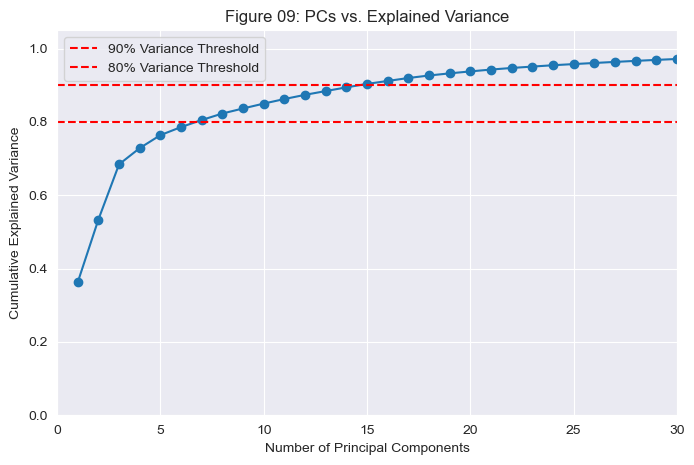

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Step 3: Compute cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Step 4: Plot n_components vs cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Figure 09: PCs vs. Explained Variance')
plt.grid(True)

plt.xlim(0, 30)
plt.ylim(0, 1.05)
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Variance Threshold')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% Variance Threshold')

plt.legend()
plt.savefig('figures/Figure 09 - Principal Component Analysis.png', dpi=600, bbox_inches='tight')
plt.show()

In [51]:
# PCA Fit
from statsmodels.multivariate.pca import PCA
pca_real = PCA(data=X, ncomp=7, standardize=True, demean=True, normalize=True)

In [70]:
# Examine PC Loadings / Coefficients
loadings_df = pca_real.coeff
loadings_df.index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']
loadings_df.loc['PC1'].sort_values(ascending=False).round(2)

ball_control      114.19
short_passing     112.96
LCM               112.58
CM                112.58
RCM               112.58
                   ...  
GK_kicking        -62.51
GK_positioning    -62.63
GK_handling       -62.94
GK_reflexes       -63.03
GK_diving         -63.13
Name: PC1, Length: 81, dtype: float64

In [72]:
# Examine the Correlation of PC Scores to Individual Features
pc_corr_df = pd.concat(objs=[X, pca_real.scores], axis=1).corr().round(2).loc[:, 'comp_0':'comp_6']
pc_corr_df = pc_corr_df.rename(mapper={'comp_0':'PC1', 'comp_1':'PC2', 'comp_2':'PC3', 'comp_3':'PC4', 'comp_4':'PC5', 'comp_5':'PC6', 'comp_6':'PC7'}, axis=1)
pc_corr_df.sort_values(by='PC1', ascending=False).iloc[1:, :]

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
ball_control,0.85,-0.09,-0.44,0.05,0.00,-0.03,-0.04
CM,0.84,0.16,0.46,-0.14,-0.08,-0.07,-0.04
short_passing,0.84,0.10,-0.39,0.00,-0.00,-0.08,-0.03
LCM,0.84,0.16,0.46,-0.14,-0.08,-0.07,-0.04
dribbling,0.84,-0.24,-0.42,-0.05,0.02,0.00,-0.04
...,...,...,...,...,...,...,...
GK_handling,-0.47,0.04,0.85,-0.06,-0.01,0.03,0.05
GK_kicking,-0.47,0.04,0.85,-0.06,-0.02,0.03,0.05
GK_positioning,-0.47,0.04,0.85,-0.05,-0.01,0.04,0.06
GK_reflexes,-0.47,0.04,0.85,-0.05,-0.01,0.04,0.05


* PC1 shares strong positive correlations (r>= 0.8) with ball control, dribbling, passing, crossing, and various mid-field offensive positions.
* PC2 shares strong positive correlations (r>= 0.84) with center-back and defensive mid-field positions.  Interceptions and tackles are also highly correlated.
* PC3 weights goalkeeping skills of handling, reflexes, diving, kicking, and positioning above all others, and shares strong positive correlations with each (r >= 0.84).
* PC4 shares a moderate positive correlation with strength (r = 0.63) and weight (r = 0.59).
* PC5 weights player value and potential the highest, but is only mildy correlated.
* PC6 seems rather unremarkable, aside from the weight it places on normal body types.